In [17]:
import matplotlib.pyplot as plt

def axis_to_data(ax, axis_coords):
    """
    Convert axis coordinates (0–1) to data coordinates.

    Parameters:
        ax (matplotlib.axes.Axes): The axes object.
        axis_coords (tuple): (x, y) in axis coordinates.

    Returns:
        tuple: (x, y) in data coordinates.
    """
    # Axis → Display → Data
    display_coords = ax.transAxes.transform(axis_coords)
    return tuple(ax.transData.inverted().transform(display_coords))


def data_to_axis(ax, data_coords):
    """
    Convert data coordinates to axis coordinates (0–1).

    Parameters:
        ax (matplotlib.axes.Axes): The axes object.
        data_coords (tuple): (x, y) in data coordinates.

    Returns:
        tuple: (x, y) in axis coordinates.
    """
    # Data → Display → Axis
    display_coords = ax.transData.transform(data_coords)
    return tuple(ax.transAxes.inverted().transform(display_coords))

# Closeup on future helioscopes

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:155: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:155: SyntaxWarning: invalid escape sequence '\M'
C:\Users\mjlynn\AppData\Local\Temp\ipykernel_12328\3059678391.py:6: SyntaxWarning: invalid escape sequence '\g'
  fig,ax = FigSetup(Shape='Rectangular',ylab='$|g_{a\gamma\gamma}|$ [GeV$^{-1}$]',mathpazo=True,\
C:\Users\mjlynn\AppData\Local\Temp\ipykernel_12328\3059678391.py:155: SyntaxWarning: invalid escape sequence '\M'
  dat = loadtxt('D:\\\Morgan\\Axion Notebooks\\AxionLimits\\20251019\\0000' + str(i) + '_20251019_Scan_Projections_VaryBeta_4K.txt', skiprows = 1)


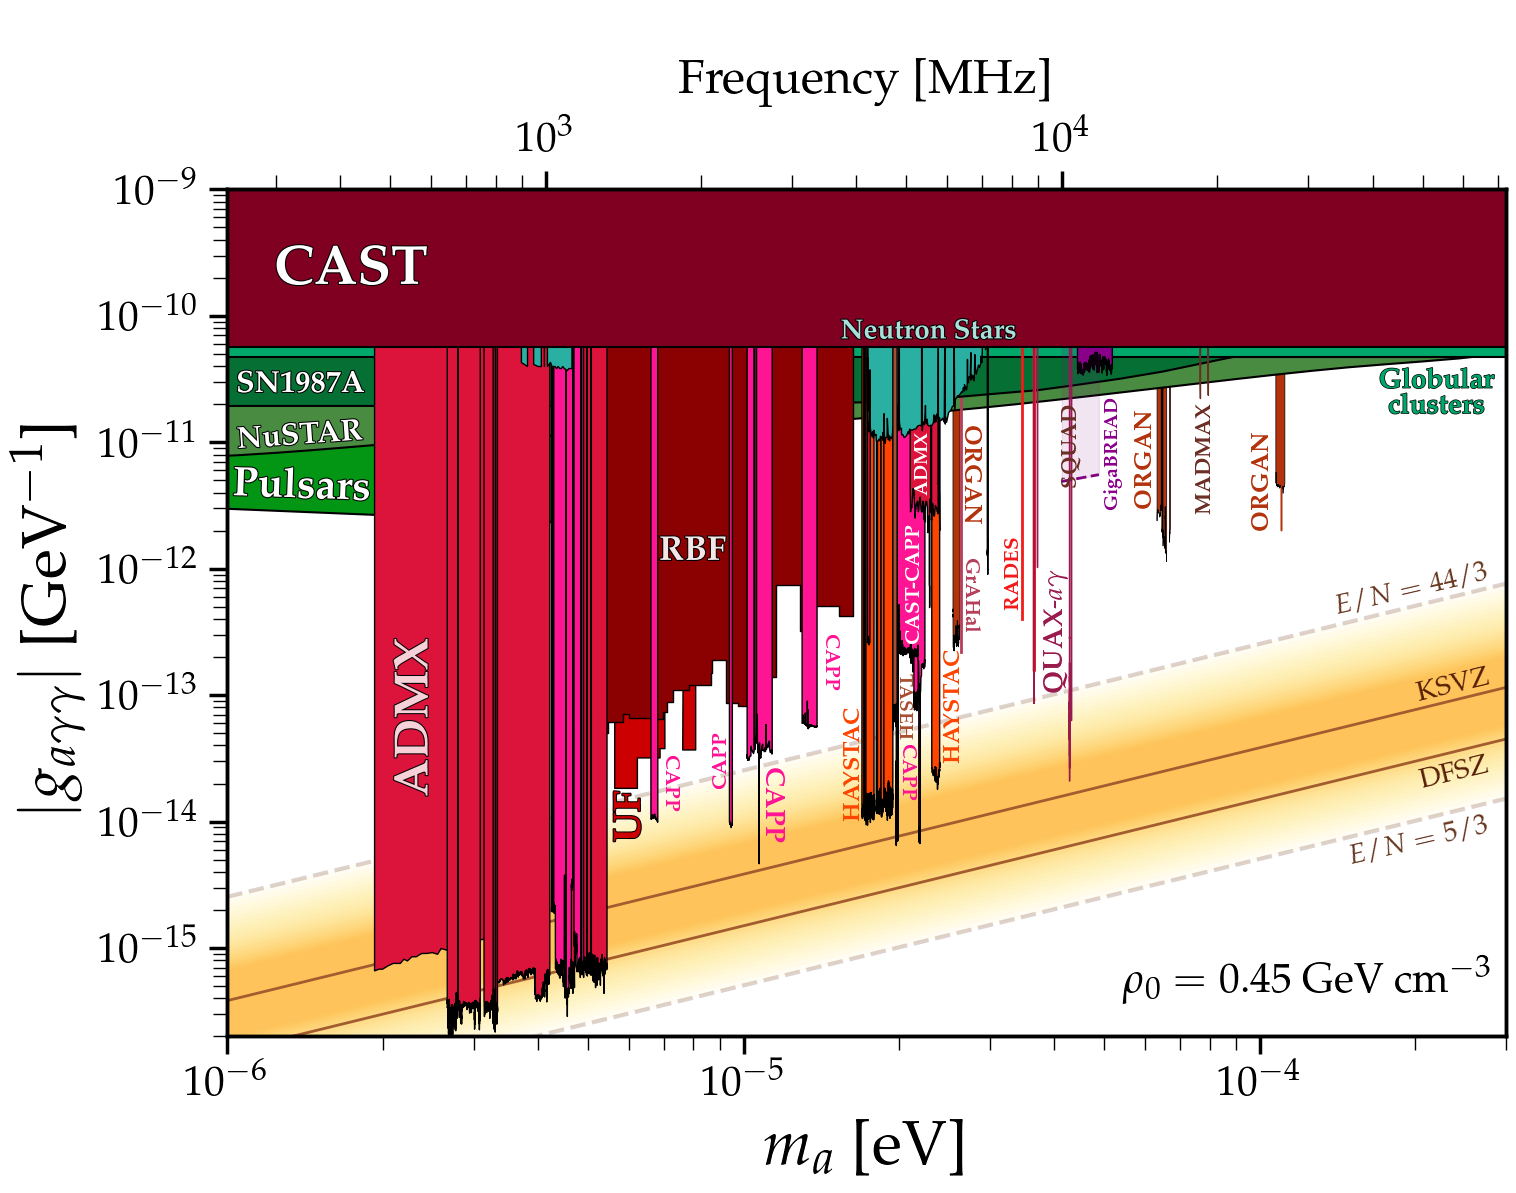

In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from PlotFuncs import BlackHoleSpins, AxionPhoton, MySaveFig, UpperFrequencyAxis,col_alpha,FigSetup,line_background

fig,ax = FigSetup(Shape='Rectangular',ylab='$|g_{a\gamma\gamma}|$ [GeV$^{-1}$]',mathpazo=True,\
                 m_min=1e-6,m_max=3e-4,g_min=2e-16,g_max=1e-9,tfs=30,xtick_rotation=0,FrequencyAxis=True,N_Hz=1e6,upper_xlabel=r"Frequency [MHz]",xlabel_pad=20)

y2 = 1e-9

ADMX_col = 'crimson'


# CAST
AxionPhoton.Helioscopes(ax,projection=False,text_on=False)
plt.gcf().text(0.2,0.805,r'{\bf CAST}',color=col_alpha(ADMX_col,0.0),fontsize=40,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

# Globular clusters
AxionPhoton.StellarBounds(ax,text_on=False)
plt.text(2.2e-4,2.7e-11,r'{\bf Globular}',color=[0.0, 0.66, 0.42],fontsize=20,path_effects=line_background(1,'k'),ha='center')
plt.text(2.2e-4,1.7e-11,r'{\bf clusters}',color=[0.0, 0.66, 0.42],fontsize=20,path_effects=line_background(1,'k'),ha='center')

# Pulars
AxionPhoton.PulsarPolarCap(ax,text_on=False)
plt.text(1.02e-6,3.5e-12,r'{\bf Pulsars}',color='w',rotation=-2,fontsize=30,path_effects=line_background(1.5,'k'))

AxionPhoton.SN1987A_gamma(ax,text_on=False)
plt.text(1.04e-6,2.5e-11,r'{\bf SN1987A}',color='w',rotation=0,fontsize=22,path_effects=line_background(1.5,'k'))

AxionPhoton.NuSTAR_Sun(ax,text_on=False)
plt.text(1.04e-6,0.9e-11,r'{\bf NuSTAR}',color='w',rotation=4,fontsize=22,path_effects=line_background(1.5,'k'))


# QCD axion
AxionPhoton.QCDAxion(ax,text_on=False,C_center=abs(5/3-1.92)*(44/3-1.92)/2,C_width=0.7)
def g_x(C_ag,m_a):
        return 2e-10*C_ag*m_a
mvals = array([1e-6,3e-4])
plt.plot(mvals,g_x(44/3-1.95,mvals),'--',lw=3,color='#572006',zorder=0.0,alpha=0.2)
plt.plot(mvals,g_x(abs(5/3-1.92),mvals),'--',lw=3,color='#572006',zorder=0.1,alpha=0.2)
plt.gcf().text(0.89,0.525,r'$E/N = 44/3$',fontsize=20,color='#572006',rotation=13,rotation_mode='anchor',ha='right',alpha=0.9)
plt.gcf().text(0.89,0.295,r'$E/N = 5/3$',fontsize=20,color='#572006',rotation=13,rotation_mode='anchor',ha='right',alpha=0.9)
plt.gcf().text(0.89,0.43,r'KSVZ',fontsize=20,color='#572006',rotation=13.5,rotation_mode='anchor',ha='right',alpha=1)
plt.gcf().text(0.89,0.35,r'DFSZ',fontsize=20,color='#572006',rotation=13.5,rotation_mode='anchor',ha='right',alpha=1)


# RBF/UF
UF_col = [0.8,0,0]
RBF_col = 'Darkred'
dat = loadtxt("limit_data/AxionPhoton/RBF.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor='darkred',zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/UF.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=[0.8,0,0],zorder=0.09)
plt.gcf().text(0.37,0.31,r'{\bf UF}',color=col_alpha(UF_col,1),fontsize=28,rotation=90,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))
plt.gcf().text(0.407,0.55,r'{\bf RBF}',color=col_alpha(RBF_col,0.1),fontsize=25,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))


# ADMX
dat = loadtxt("limit_data/AxionPhoton/ADMX.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2018.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2019_1.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2019_2.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2021.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2024.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2025.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
plt.gcf().text(0.24,0.4,r'{\bf ADMX}',color=col_alpha(ADMX_col,0.2),fontsize=35,rotation=90,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

#HAYSTAC
HAYSTAC_col = 'orangered'
dat1 = loadtxt("limit_data/AxionPhoton/HAYSTAC_PhaseI.txt")
dat2 = loadtxt("limit_data/AxionPhoton/HAYSTAC_PhaseII_ab.txt")
dat3 = loadtxt("limit_data/AxionPhoton/HAYSTAC_PhaseII_cd.txt")
plt.fill_between(dat1[:,0],dat1[:,1],y2=y2,edgecolor='k',facecolor=HAYSTAC_col,zorder=0.1)
plt.fill_between(dat2[:,0],dat2[:,1],y2=y2,edgecolor='k',facecolor=HAYSTAC_col,zorder=0.1)
plt.fill_between(dat3[:,0],dat3[:,1],y2=y2,edgecolor='k',facecolor=HAYSTAC_col,zorder=0.1)
plt.gcf().text(0.505,0.357,r'{\bf HAYSTAC}',color=col_alpha(HAYSTAC_col,1),fontsize=17,rotation=90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.566,0.41,r'{\bf HAYSTAC}',color=col_alpha(HAYSTAC_col,1),fontsize=17,rotation=90,rotation_mode='anchor',ha='center',va='center')


#CAPP
CAPP_col = 'deeppink'
for file in ['CAPP-1','CAPP-2','CAPP-3','CAPP-4','CAPP-5','CAPP-6','CAPP-7','CAPP-8','CAPP-9','CAPP-MAX']:
    dat1 = loadtxt("limit_data/AxionPhoton/"+file+".txt")
    plt.fill_between(dat1[:,0],dat1[:,1],y2=y2,edgecolor='k',facecolor=CAPP_col,zorder=0.1)
plt.gcf().text(0.455,0.32,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=20,rotation=-90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.49,0.45,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=15,rotation=-90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.393,0.34,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=15,rotation=-90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.537,0.35,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=15,rotation=-90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.425,0.36,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=15,rotation=90,rotation_mode='anchor',ha='center',va='center')

#ORGAN
ORGAN_col = [0.7,0.2,0.05]
AxionPhoton.ORGAN(ax,text_on=False,col=ORGAN_col)
plt.gcf().text(0.753,0.615,r'{\bf ORGAN}',color=col_alpha(ORGAN_col,1),fontsize=18,rotation=90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.682,0.635,r'{\bf ORGAN}',color=col_alpha(ORGAN_col,1),fontsize=18,rotation=90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.575,0.62,r'{\bf ORGAN}',color=col_alpha(ORGAN_col,1),fontsize=18,rotation=-90,rotation_mode='anchor',ha='center',va='center')


# TASEH
TASEH_col = '#a84e32'
dat = loadtxt("limit_data/AxionPhoton/TASEH.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=TASEH_col,zorder=0.4)
plt.gcf().text(0.535,0.41,r'{\bf TASEH}',color=col_alpha(TASEH_col,1),fontsize=14,rotation=-90,rotation_mode='anchor',ha='center',va='center')

# GrAHal
GrAHal_col = '#b53e5a'
AxionPhoton.GrAHal(ax,text_on=False,col=GrAHal_col)
plt.gcf().text(0.575,0.51,r'{\bf GrAHal}',color=col_alpha(GrAHal_col,1),fontsize=15,rotation=-90,rotation_mode='anchor',ha='center',va='center')


# CAST-CAPP
dat = loadtxt("limit_data/AxionPhoton/CAST-CAPP.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=CAPP_col,zorder=0.1)
plt.gcf().text(0.542,0.52,r'{\bf CAST-CAPP}',color='w',fontsize=15,rotation=90,rotation_mode='anchor',ha='center',va='center')


# ADMX Sidecar
dat = loadtxt("limit_data/AxionPhoton/ADMX_Sidecar.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX_Sidecar_JTWPA.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
plt.gcf().text(0.547,0.63,r'{\bf ADMX}',color='w',fontsize=14,rotation=90,rotation_mode='anchor',ha='center',va='center')


# GigaBREAD
dat = loadtxt("limit_data/AxionPhoton/GigaBREAD.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor='darkmagenta',zorder=0.1)
#plt.text(48e-6,0.8e-11,r'{\bf GigaBREAD}',color='darkmagenta',fontsize=14,rotation=90,rotation_mode='anchor',ha='center',va='center')
plt.text(52e-6,0.8e-11,r'{\bf GigaBREAD}',color='darkmagenta',fontsize=14,rotation=90,rotation_mode='anchor',ha='center',va='center')


# QUAX
QUAX_col = [0.6,0.1,0.3]
dat = loadtxt("limit_data/AxionPhoton/QUAX.txt")
dat2 = loadtxt("limit_data/AxionPhoton/QUAX2.txt")
dat3 = loadtxt("limit_data/AxionPhoton/QUAX4.txt") # supersedes QUAX3.txt
dat4 = loadtxt("limit_data/AxionPhoton/QUAX5.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor=QUAX_col,facecolor=ADMX_col,zorder=0.1)
plt.fill_between(dat2[:,0],dat2[:,1],y2=y2,edgecolor=QUAX_col,facecolor=ADMX_col,zorder=0.1)
plt.fill_between(dat3[:,0],dat3[:,1],y2=y2,edgecolor=QUAX_col,facecolor=ADMX_col,zorder=0.1)
plt.fill_between(dat4[:,0],dat4[:,1],y2=y2,edgecolor=QUAX_col,facecolor=ADMX_col,zorder=0.1)
plt.gcf().text(0.627,0.479,r'{\bf QUAX}-$a\gamma$',color=col_alpha(QUAX_col,1),fontsize=20,rotation=90,rotation_mode='anchor',ha='center',va='center')

#SQUAD Projections
#Betas = np.linspace(1,10, 10)
Betas = [10]
for i,j in enumerate(Betas):
    dat = loadtxt('D:\\\Morgan\\Axion Notebooks\\AxionLimits\\20251019\\0000' + str(i) + '_20251019_Scan_Projections_VaryBeta_4K.txt', skiprows = 1)
    plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='purple', facecolor = 'purple', zorder=i + 0.11, alpha=0.1)
    plt.plot(dat[:,0],dat[:,1],'--',linewidth=2,color='purple', zorder=i + 0.11)
    #plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='#6b2e25',facecolor='#6b2e25',zorder=i + 0.11)
    print()
    plt.text(dat[:,0][0],dat[:,1][0],r'{\bf SQUAD}',color='#6b2e25',rotation=90,fontsize=16)


# RADES
RADES_col = [0.95,0.1,0.1]
dat = loadtxt("limit_data/AxionPhoton/RADES.txt")
plt.plot([dat[0,0],dat[0,0]],[dat[0,1],y2],color=RADES_col,lw=2,zorder=0.05)
dat = loadtxt("limit_data/AxionPhoton/RADES2.txt")
plt.plot(dat[:,0],dat[:,1],color=RADES_col,lw=2,zorder=0.05)
plt.gcf().text(0.602,0.53,r'{\bf RADES}',color=col_alpha(RADES_col,1),fontsize=15,rotation=90,rotation_mode='anchor',ha='center',va='center')


# MADMAX
dat = loadtxt('limit_data/AxionPhoton/MADMAX.txt')
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='#6b2e25',facecolor='#6b2e25',zorder=0.11)
plt.text(75e-6,3e-12,r'{\bf MADMAX}',color='#6b2e25',rotation=90,fontsize=16)


plt.title('0',color='w',pad=10)
plt.gcf().text(0.89,0.15,r'$\rho_0 = 0.45$ GeV cm$^{-3}$',fontsize=30,ha='right')

MySaveFig(fig,'AxionPhoton_RadioFreqCloseup_noNS')

plt.gcf().text(0.55,0.75,r'{\bf Neutron Stars}',color=col_alpha('#2ab0a3',0.4),fontsize=20,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))
dat = loadtxt('limit_data/AxionPhoton/NeutronStars_BreakthroughListen.txt')
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor='#2ab0a3',zorder=0.11)

dat = loadtxt('limit_data/AxionPhoton/NeutronStars_Battye2.txt')
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor='#2ab0a3',zorder=0.11)


MySaveFig(fig,'AxionPhoton_RadioFreqCloseup')

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:154: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:154: SyntaxWarning: invalid escape sequence '\M'
C:\Users\mjlynn\AppData\Local\Temp\ipykernel_12328\930156332.py:6: SyntaxWarning: invalid escape sequence '\g'
  fig,ax = FigSetup(Shape='Rectangular',ylab='$|g_{a\gamma\gamma}|$ [GeV$^{-1}$]',mathpazo=True,\
C:\Users\mjlynn\AppData\Local\Temp\ipykernel_12328\930156332.py:154: SyntaxWarning: invalid escape sequence '\M'
  dat = loadtxt('D:\\\Morgan\\Axion Notebooks\\AxionLimits\\20251019\\0000' + str(i) + '_20251019_Scan_Projections_VaryBeta_4K.txt', skiprows = 1)


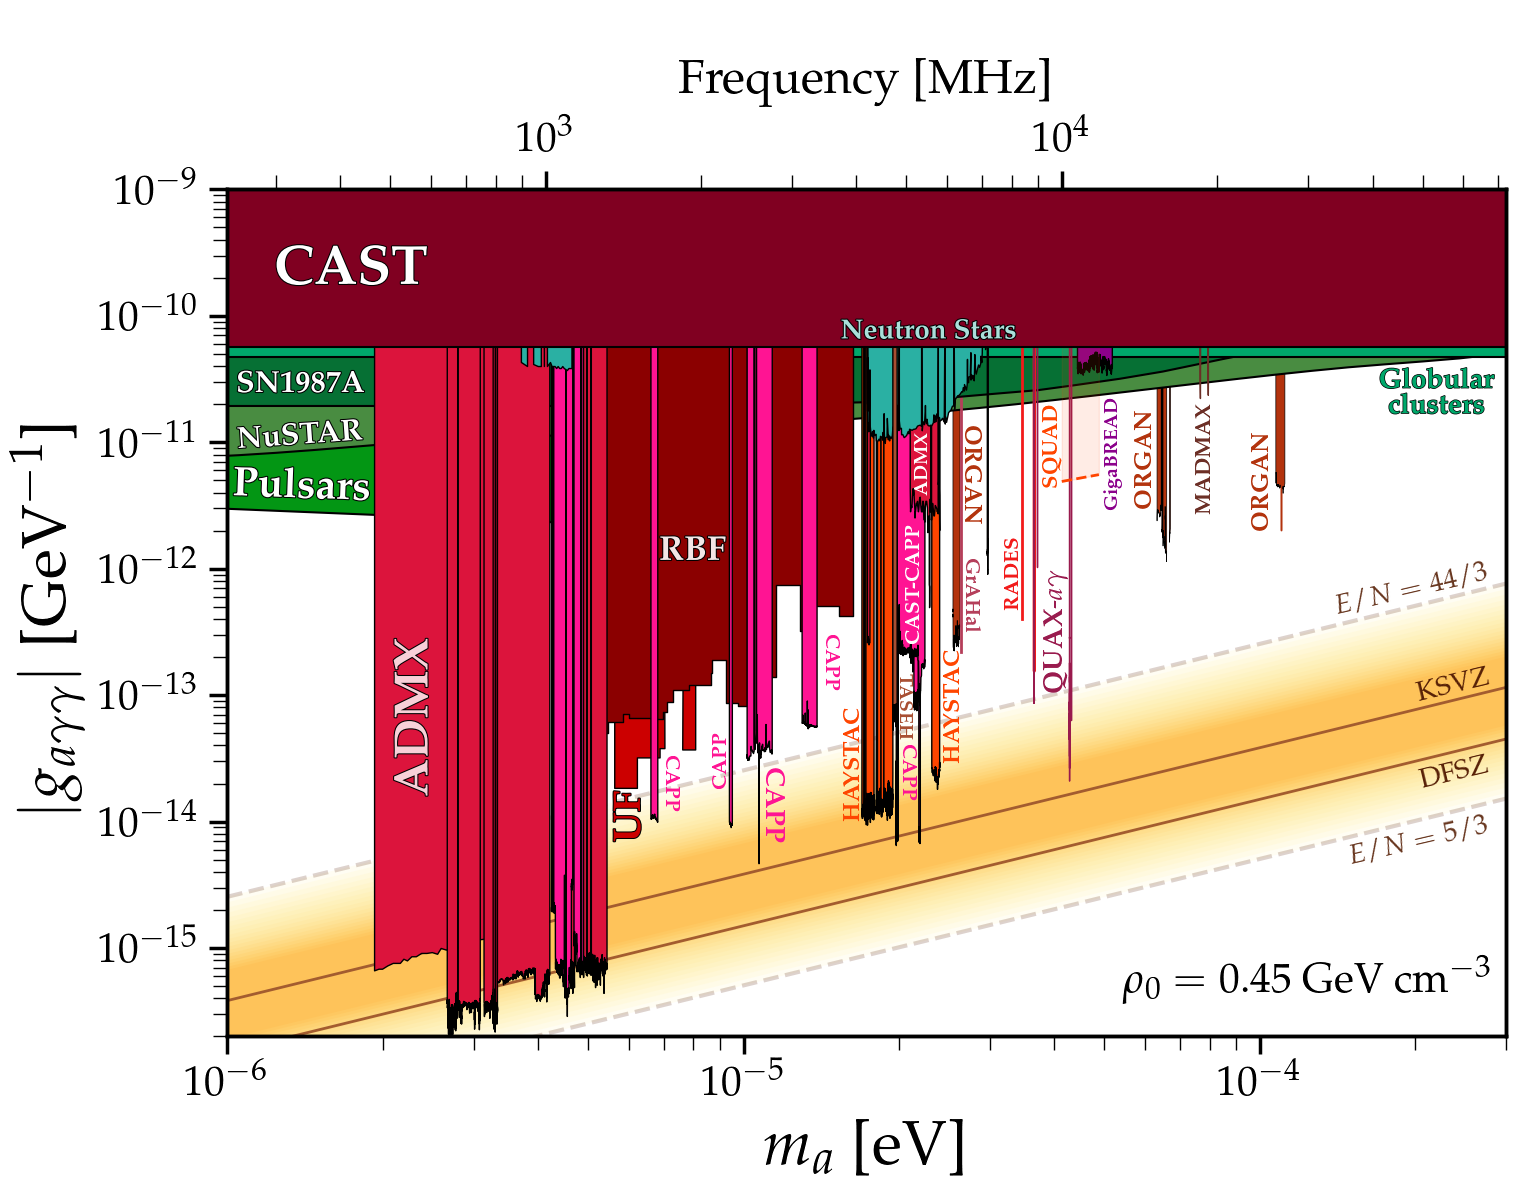

In [30]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from PlotFuncs import BlackHoleSpins, AxionPhoton, MySaveFig, UpperFrequencyAxis,col_alpha,FigSetup,line_background

fig,ax = FigSetup(Shape='Rectangular',ylab='$|g_{a\gamma\gamma}|$ [GeV$^{-1}$]',mathpazo=True,\
                 m_min=1e-6,m_max=3e-4,g_min=2e-16,g_max=1e-9,tfs=30,xtick_rotation=0,FrequencyAxis=True,N_Hz=1e6,upper_xlabel=r"Frequency [MHz]",xlabel_pad=20)

y2 = 1e-9

ADMX_col = 'crimson'


# CAST
AxionPhoton.Helioscopes(ax,projection=False,text_on=False)
plt.gcf().text(0.2,0.805,r'{\bf CAST}',color=col_alpha(ADMX_col,0.0),fontsize=40,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

# Globular clusters
AxionPhoton.StellarBounds(ax,text_on=False)
plt.text(2.2e-4,2.7e-11,r'{\bf Globular}',color=[0.0, 0.66, 0.42],fontsize=20,path_effects=line_background(1,'k'),ha='center')
plt.text(2.2e-4,1.7e-11,r'{\bf clusters}',color=[0.0, 0.66, 0.42],fontsize=20,path_effects=line_background(1,'k'),ha='center')

# Pulars
AxionPhoton.PulsarPolarCap(ax,text_on=False)
plt.text(1.02e-6,3.5e-12,r'{\bf Pulsars}',color='w',rotation=-2,fontsize=30,path_effects=line_background(1.5,'k'))

AxionPhoton.SN1987A_gamma(ax,text_on=False)
plt.text(1.04e-6,2.5e-11,r'{\bf SN1987A}',color='w',rotation=0,fontsize=22,path_effects=line_background(1.5,'k'))

AxionPhoton.NuSTAR_Sun(ax,text_on=False)
plt.text(1.04e-6,0.9e-11,r'{\bf NuSTAR}',color='w',rotation=4,fontsize=22,path_effects=line_background(1.5,'k'))

# QCD axion
AxionPhoton.QCDAxion(ax,text_on=False,C_center=abs(5/3-1.92)*(44/3-1.92)/2,C_width=0.7)
def g_x(C_ag,m_a):
        return 2e-10*C_ag*m_a
mvals = array([1e-6,3e-4])
plt.plot(mvals,g_x(44/3-1.95,mvals),'--',lw=3,color='#572006',zorder=0.0,alpha=0.2)
plt.plot(mvals,g_x(abs(5/3-1.92),mvals),'--',lw=3,color='#572006',zorder=0.1,alpha=0.2)
plt.gcf().text(0.89,0.525,r'$E/N = 44/3$',fontsize=20,color='#572006',rotation=13,rotation_mode='anchor',ha='right',alpha=0.9)
plt.gcf().text(0.89,0.295,r'$E/N = 5/3$',fontsize=20,color='#572006',rotation=13,rotation_mode='anchor',ha='right',alpha=0.9)
plt.gcf().text(0.89,0.43,r'KSVZ',fontsize=20,color='#572006',rotation=13.5,rotation_mode='anchor',ha='right',alpha=1)
plt.gcf().text(0.89,0.35,r'DFSZ',fontsize=20,color='#572006',rotation=13.5,rotation_mode='anchor',ha='right',alpha=1)


# RBF/UF
UF_col = [0.8,0,0]
RBF_col = 'Darkred'
dat = loadtxt("limit_data/AxionPhoton/RBF.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor='darkred',zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/UF.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=[0.8,0,0],zorder=0.09)
plt.gcf().text(0.37,0.31,r'{\bf UF}',color=col_alpha(UF_col,1),fontsize=28,rotation=90,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))
plt.gcf().text(0.407,0.55,r'{\bf RBF}',color=col_alpha(RBF_col,0.1),fontsize=25,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))


# ADMX
dat = loadtxt("limit_data/AxionPhoton/ADMX.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2018.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2019_1.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2019_2.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2021.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2024.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX2025.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
plt.gcf().text(0.24,0.4,r'{\bf ADMX}',color=col_alpha(ADMX_col,0.2),fontsize=35,rotation=90,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

#HAYSTAC
HAYSTAC_col = 'orangered'
dat1 = loadtxt("limit_data/AxionPhoton/HAYSTAC_PhaseI.txt")
dat2 = loadtxt("limit_data/AxionPhoton/HAYSTAC_PhaseII_ab.txt")
dat3 = loadtxt("limit_data/AxionPhoton/HAYSTAC_PhaseII_cd.txt")
plt.fill_between(dat1[:,0],dat1[:,1],y2=y2,edgecolor='k',facecolor=HAYSTAC_col,zorder=0.1)
plt.fill_between(dat2[:,0],dat2[:,1],y2=y2,edgecolor='k',facecolor=HAYSTAC_col,zorder=0.1)
plt.fill_between(dat3[:,0],dat3[:,1],y2=y2,edgecolor='k',facecolor=HAYSTAC_col,zorder=0.1)
plt.gcf().text(0.505,0.357,r'{\bf HAYSTAC}',color=col_alpha(HAYSTAC_col,1),fontsize=17,rotation=90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.566,0.41,r'{\bf HAYSTAC}',color=col_alpha(HAYSTAC_col,1),fontsize=17,rotation=90,rotation_mode='anchor',ha='center',va='center')


#CAPP
CAPP_col = 'deeppink'
for file in ['CAPP-1','CAPP-2','CAPP-3','CAPP-4','CAPP-5','CAPP-6','CAPP-7','CAPP-8','CAPP-9','CAPP-MAX']:
    dat1 = loadtxt("limit_data/AxionPhoton/"+file+".txt")
    plt.fill_between(dat1[:,0],dat1[:,1],y2=y2,edgecolor='k',facecolor=CAPP_col,zorder=0.1)
plt.gcf().text(0.455,0.32,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=20,rotation=-90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.49,0.45,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=15,rotation=-90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.393,0.34,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=15,rotation=-90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.537,0.35,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=15,rotation=-90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.425,0.36,r'{\bf CAPP}',color=col_alpha(CAPP_col,1),fontsize=15,rotation=90,rotation_mode='anchor',ha='center',va='center')

#ORGAN
ORGAN_col = [0.7,0.2,0.05]
AxionPhoton.ORGAN(ax,text_on=False,col=ORGAN_col)
plt.gcf().text(0.753,0.615,r'{\bf ORGAN}',color=col_alpha(ORGAN_col,1),fontsize=18,rotation=90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.682,0.635,r'{\bf ORGAN}',color=col_alpha(ORGAN_col,1),fontsize=18,rotation=90,rotation_mode='anchor',ha='center',va='center')
plt.gcf().text(0.575,0.62,r'{\bf ORGAN}',color=col_alpha(ORGAN_col,1),fontsize=18,rotation=-90,rotation_mode='anchor',ha='center',va='center')


# TASEH
TASEH_col = '#a84e32'
dat = loadtxt("limit_data/AxionPhoton/TASEH.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=TASEH_col,zorder=0.4)
plt.gcf().text(0.535,0.41,r'{\bf TASEH}',color=col_alpha(TASEH_col,1),fontsize=14,rotation=-90,rotation_mode='anchor',ha='center',va='center')

# GrAHal
GrAHal_col = '#b53e5a'
AxionPhoton.GrAHal(ax,text_on=False,col=GrAHal_col)
plt.gcf().text(0.575,0.51,r'{\bf GrAHal}',color=col_alpha(GrAHal_col,1),fontsize=15,rotation=-90,rotation_mode='anchor',ha='center',va='center')


# CAST-CAPP
dat = loadtxt("limit_data/AxionPhoton/CAST-CAPP.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=CAPP_col,zorder=0.1)
plt.gcf().text(0.542,0.52,r'{\bf CAST-CAPP}',color='w',fontsize=15,rotation=90,rotation_mode='anchor',ha='center',va='center')


# ADMX Sidecar
dat = loadtxt("limit_data/AxionPhoton/ADMX_Sidecar.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
dat = loadtxt("limit_data/AxionPhoton/ADMX_Sidecar_JTWPA.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor=ADMX_col,zorder=0.1)
plt.gcf().text(0.547,0.63,r'{\bf ADMX}',color='w',fontsize=14,rotation=90,rotation_mode='anchor',ha='center',va='center')


# GigaBREAD
dat = loadtxt("limit_data/AxionPhoton/GigaBREAD.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor='darkmagenta',zorder=0.1)
#plt.text(48e-6,0.8e-11,r'{\bf GigaBREAD}',color='darkmagenta',fontsize=14,rotation=90,rotation_mode='anchor',ha='center',va='center')
plt.text(52e-6,0.8e-11,r'{\bf GigaBREAD}',color='darkmagenta',fontsize=14,rotation=90,rotation_mode='anchor',ha='center',va='center')

# QUAX
QUAX_col = [0.6,0.1,0.3]
dat = loadtxt("limit_data/AxionPhoton/QUAX.txt")
dat2 = loadtxt("limit_data/AxionPhoton/QUAX2.txt")
dat3 = loadtxt("limit_data/AxionPhoton/QUAX4.txt") # supersedes QUAX3.txt
dat4 = loadtxt("limit_data/AxionPhoton/QUAX5.txt")
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor=QUAX_col,facecolor=ADMX_col,zorder=0.1)
plt.fill_between(dat2[:,0],dat2[:,1],y2=y2,edgecolor=QUAX_col,facecolor=ADMX_col,zorder=0.1)
plt.fill_between(dat3[:,0],dat3[:,1],y2=y2,edgecolor=QUAX_col,facecolor=ADMX_col,zorder=0.1)
plt.fill_between(dat4[:,0],dat4[:,1],y2=y2,edgecolor=QUAX_col,facecolor=ADMX_col,zorder=0.1)
plt.gcf().text(0.627,0.479,r'{\bf QUAX}-$a\gamma$',color=col_alpha(QUAX_col,1),fontsize=20,rotation=90,rotation_mode='anchor',ha='center',va='center')

#SQUAD Projections
#Betas = np.linspace(1,10, 10)
Betas = [10]
SQUAD_col = 'orangered'
for i,j in enumerate(Betas):
    dat = loadtxt('D:\\\Morgan\\Axion Notebooks\\AxionLimits\\20251019\\0000' + str(i) + '_20251019_Scan_Projections_VaryBeta_4K.txt', skiprows = 1)
    plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor=SQUAD_col, facecolor = SQUAD_col, zorder=i + 0.11, alpha=0.1)
    plt.plot(dat[:,0],dat[:,1],'--',linewidth=2,color=SQUAD_col, zorder=i + 0.11)
    #plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='#6b2e25',facecolor='#6b2e25',zorder=i + 0.11)
    #print(dat[:,0][0], dat[:,1][0])
    plt.text(3.8e-05,dat[:,1][0],r'{\bf SQUAD}',color=SQUAD_col,rotation=90,fontsize=16)

# RADES
RADES_col = [0.95,0.1,0.1]
dat = loadtxt("limit_data/AxionPhoton/RADES.txt")
plt.plot([dat[0,0],dat[0,0]],[dat[0,1],y2],color=RADES_col,lw=2,zorder=0.05)
dat = loadtxt("limit_data/AxionPhoton/RADES2.txt")
plt.plot(dat[:,0],dat[:,1],color=RADES_col,lw=2,zorder=0.05)
plt.gcf().text(0.602,0.53,r'{\bf RADES}',color=col_alpha(RADES_col,1),fontsize=15,rotation=90,rotation_mode='anchor',ha='center',va='center')

# MADMAX
dat = loadtxt('limit_data/AxionPhoton/MADMAX.txt')
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='#6b2e25',facecolor='#6b2e25',zorder=0.11)
plt.text(75e-6,3e-12,r'{\bf MADMAX}',color='#6b2e25',rotation=90,fontsize=16)


plt.title('0',color='w',pad=10)
plt.gcf().text(0.89,0.15,r'$\rho_0 = 0.45$ GeV cm$^{-3}$',fontsize=30,ha='right')

MySaveFig(fig,'AxionPhoton_RadioFreqCloseup_noNS')

plt.gcf().text(0.55,0.75,r'{\bf Neutron Stars}',color=col_alpha('#2ab0a3',0.4),fontsize=20,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))
dat = loadtxt('limit_data/AxionPhoton/NeutronStars_BreakthroughListen.txt')
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor='#2ab0a3',zorder=0.11)

dat = loadtxt('limit_data/AxionPhoton/NeutronStars_Battye2.txt')
plt.fill_between(dat[:,0],dat[:,1],y2=y2,edgecolor='k',facecolor='#2ab0a3',zorder=0.11)


MySaveFig(fig,'AxionPhoton_RadioFreqCloseup')

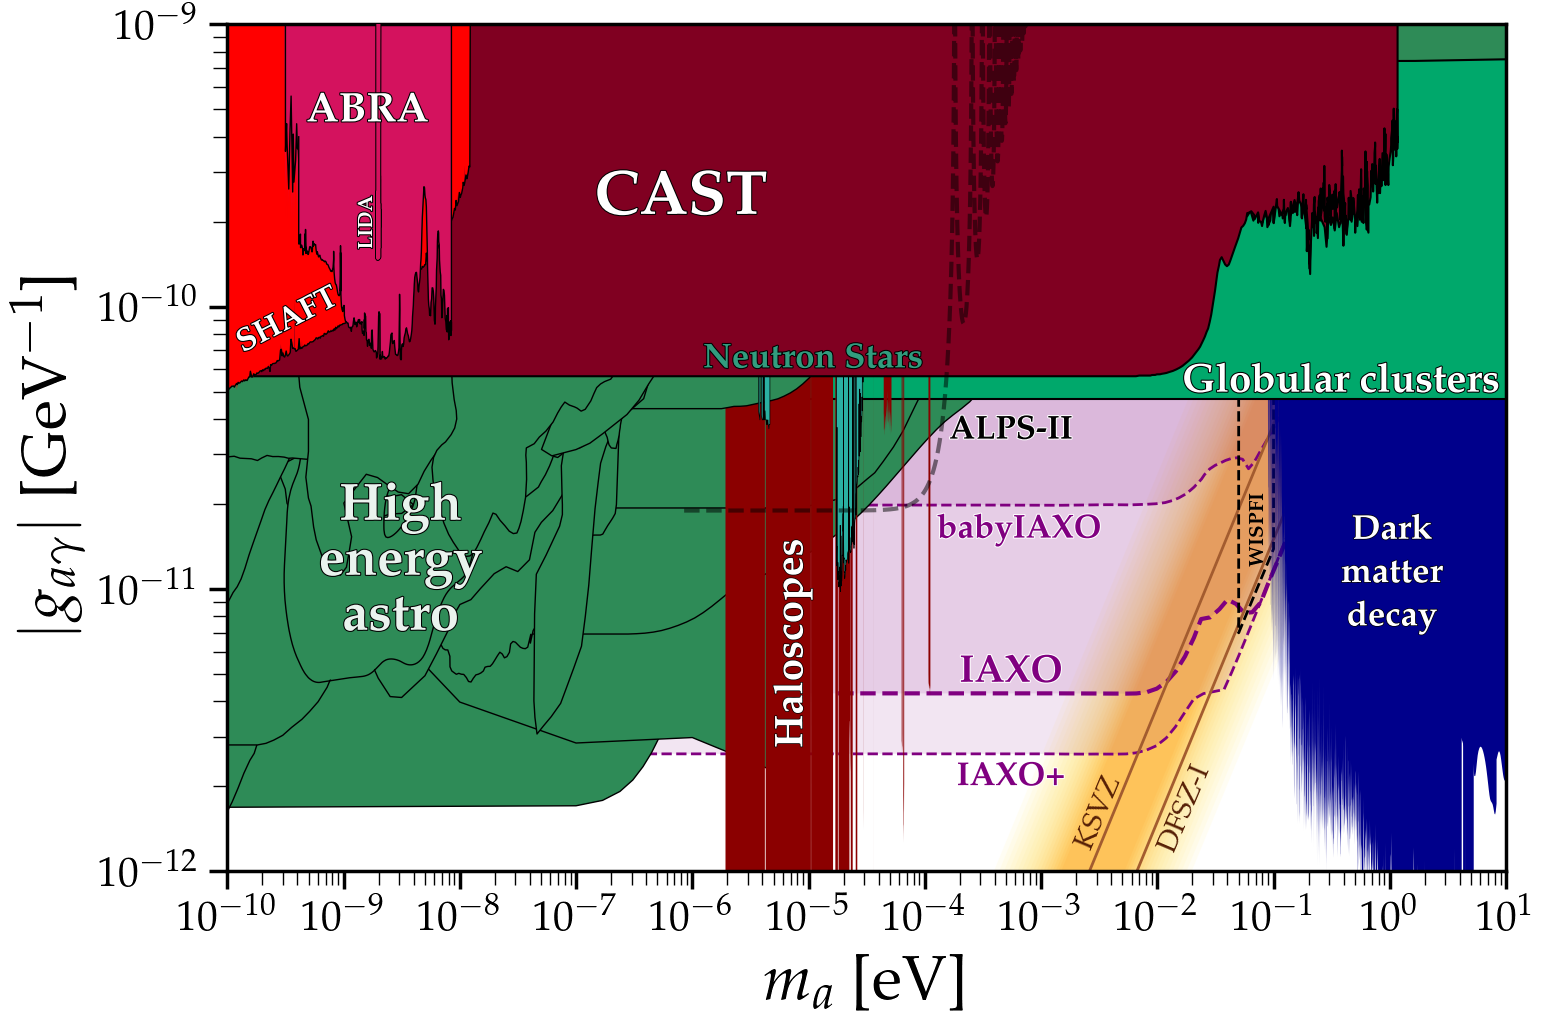

In [19]:
%matplotlib inline
from numpy import *
import matplotlib.pyplot as plt
from PlotFuncs import BlackHoleSpins, AxionPhoton, MySaveFig, col_alpha, FigSetup,line_background, PlotBound
import matplotlib.patheffects as pe
fig,ax = FigSetup(Shape='Rectangular',ylab='$|g_{a\gamma}|$ [GeV$^{-1}$]',mathpazo=True,xtick_rotation=0,tfs=30)

AxionPhoton.Helioscopes(ax,projection=False,text_on=False)

ax.set_ylim([1e-12,1e-9])
ax.set_xlim([1e-10,1e1])
y2 = ax.get_ylim()[1]

zo=-100
IAXO_col = 'purple'
IAXO = loadtxt("limit_data/AxionPhoton/Projections/babyIAXO.txt")
plt.fill_between(IAXO[:,0],IAXO[:,1],y2=y2,edgecolor=None,facecolor=IAXO_col,zorder=zo,alpha=0.1)
plt.plot(IAXO[:,0],IAXO[:,1],'--',linewidth=2,color=IAXO_col,zorder=zo)

IAXO = loadtxt("limit_data/AxionPhoton/Projections/IAXO.txt")
plt.fill_between(IAXO[:,0],IAXO[:,1],y2=y2,edgecolor=None,facecolor=IAXO_col,zorder=zo,alpha=0.1)
plt.plot(IAXO[:,0],IAXO[:,1],'--',linewidth=3,color=IAXO_col,zorder=zo)

IAXO = loadtxt("limit_data/AxionPhoton/Projections/IAXO_plus.txt")
plt.fill_between(IAXO[:,0],IAXO[:,1],y2=y2,edgecolor=None,facecolor=IAXO_col,zorder=zo,alpha=0.1)
plt.plot(IAXO[:,0],IAXO[:,1],'--',linewidth=2,color=IAXO_col,zorder=zo)

# IAXO = loadtxt("limit_data/AxionPhoton/Projections/IAXO_plus_SN_Spica1.txt")
# plt.fill_between(IAXO[:,0],IAXO[:,1],y2=y2,edgecolor=None,facecolor=IAXO_col,zorder=zo,alpha=0.1)
# plt.plot(IAXO[:,0],IAXO[:,1],':',linewidth=3,color=IAXO_col,zorder=zo)


AxionPhoton.ALPS(ax,projection=True,text_on=False,lsty_proj='--',lw_proj=3,col_proj='k',block=True)

AxionPhoton.WISPFI(ax,text_on=False)
plt.text(0.06,2.2e-11,r'{\bf WISPFI}',rotation=90,fontsize=15,color='k',ha='left',va='top',clip_on=True,alpha=1)

ADMX_col = 'darkred'
PlotBound(ax,"limit_data/AxionPhoton/Haloscopes_Combined_microeV-meV.txt",facecolor='darkred',zorder=0.1,lw=0)
AxionPhoton.ABRACADABRA(ax,text_on=False)
AxionPhoton.LIDA(ax,text_on=False)
AxionPhoton.SHAFT(ax,text_on=False)

AxionPhoton.Mrk421(ax,text_on=False,col='SeaGreen',lw=1)
AxionPhoton.NGC1275(ax,text_on=False,col='SeaGreen',lw=1)
AxionPhoton.HESS(ax,text_on=False,col='SeaGreen',lw=1)
AxionPhoton.StarClusters(ax,text_on=False,col='SeaGreen',lw=1)
AxionPhoton.SN1987A_gamma(ax,text_on=False,col='SeaGreen',lw=1)
AxionPhoton.Fermi(ax,text_on=False,col='SeaGreen',lw=1)
AxionPhoton.FermiQuasars(ax,text_on=False,col='SeaGreen',lw=1)
AxionPhoton.MUSE(ax,text_on=False,lw=1,col='darkblue')
AxionPhoton.JWST(ax,text_on=False,lw=1,col='darkblue')
AxionPhoton.WINERED(ax,text_on=False,lw=1,col='darkblue')
AxionPhoton.VIMOS(ax,text_on=False,lw=1,col='darkblue')
AxionPhoton.DESI(ax,text_on=False,lw=1,col='darkblue')
AxionPhoton.MWDPolarisation(ax,col='seagreen',text_on=False,lw=1)
AxionPhoton.MWDXrays(ax,col='seagreen',text_on=False,lw=1)
AxionPhoton.MAGIC(ax,col='seagreen',text_on=False,lw=1)
AxionPhoton.M82(ax,col='seagreen',text_on=False,lw=1)
AxionPhoton.HAWC(ax,col='seagreen',text_on=False,lw=1)
AxionPhoton.PulsarPolarCap(ax,col='seagreen',text_on=False,lw=1)
AxionPhoton.NuSTAR_Sun(ax,col='seagreen',text_on=False,lw=1)
AxionPhoton.QCDAxion(ax,text_on=False)
AxionPhoton.SolarNu(ax,text_on=False)
AxionPhoton.NeutronStars(ax,text_on=False,xskip=1,lw=0.5)
AxionPhoton.GlobularClusters(ax,text_on=False)


plt.gcf().text(0.4,0.72,r'{\bf CAST}',color=col_alpha(ADMX_col,0.0),fontsize=45,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))


plt.gcf().text(0.8,0.554,r'{\bf Globular clusters}',color='w',fontsize=29,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

plt.gcf().text(0.48,0.575,r'{\bf Neutron Stars}',color='#329c7e',fontsize=25,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))


plt.gcf().text(0.21,0.8,r'{\bf ABRA}',color='w',fontsize=30,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

plt.gcf().text(0.21,0.7,r'{\bf LIDA}',color='w',fontsize=15,rotation=90,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))


plt.gcf().text(0.162,0.61,r'{\bf SHAFT}',color='w',fontsize=23,rotation=27,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

ya = 0.44
xa = 0.23
plt.gcf().text(xa,ya,r'{\bf High}',color=col_alpha('Seagreen',0.1),fontsize=38,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))
plt.gcf().text(xa,ya-0.05,r'{\bf energy}',color=col_alpha('Seagreen',0.1),fontsize=38,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))
plt.gcf().text(xa,ya-0.1,r'{\bf astro}',color=col_alpha('Seagreen',0.1),fontsize=38,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

plt.text(5e-6,0.3e-11,r'{\bf Haloscopes}',color='w',rotation=90,fontsize=29,path_effects=line_background(1,'k'))


plt.gcf().text(0.60,0.51,r'{\bf ALPS-II}',color='k',fontsize=24,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'w'))
plt.gcf().text(0.605,0.42,r'{\bf babyIAXO}',color=IAXO_col,fontsize=24,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'w'))
plt.gcf().text(0.6,0.29,r'{\bf IAXO}',color=IAXO_col,fontsize=28,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'w'))
plt.gcf().text(0.6,0.195,r'{\bf IAXO+}',color=IAXO_col,fontsize=24,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'w'))
#plt.gcf().text(0.78,0.24,r'{\bf IAXO} (SN)',color=IAXO_col,fontsize=20,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'w'))

plt.gcf().text(0.8,0.38,r'\begin{center}{\bf Dark \linebreak matter \linebreak decay}\end{center}',color='w',fontsize=25,rotation=0,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1,'k'))

plt.gcf().text(0.645,0.13,r'KSVZ',color='#572006',fontsize=21,rotation=67,rotation_mode='anchor',ha='left',va='center')
plt.gcf().text(0.695,0.128,r'DFSZ-I',color='#572006',fontsize=21,rotation=67,rotation_mode='anchor',ha='left',va='center')

MySaveFig(fig,'AxionPhoton_IAXOCloseup')

# High energy astrophysics bounds close-up

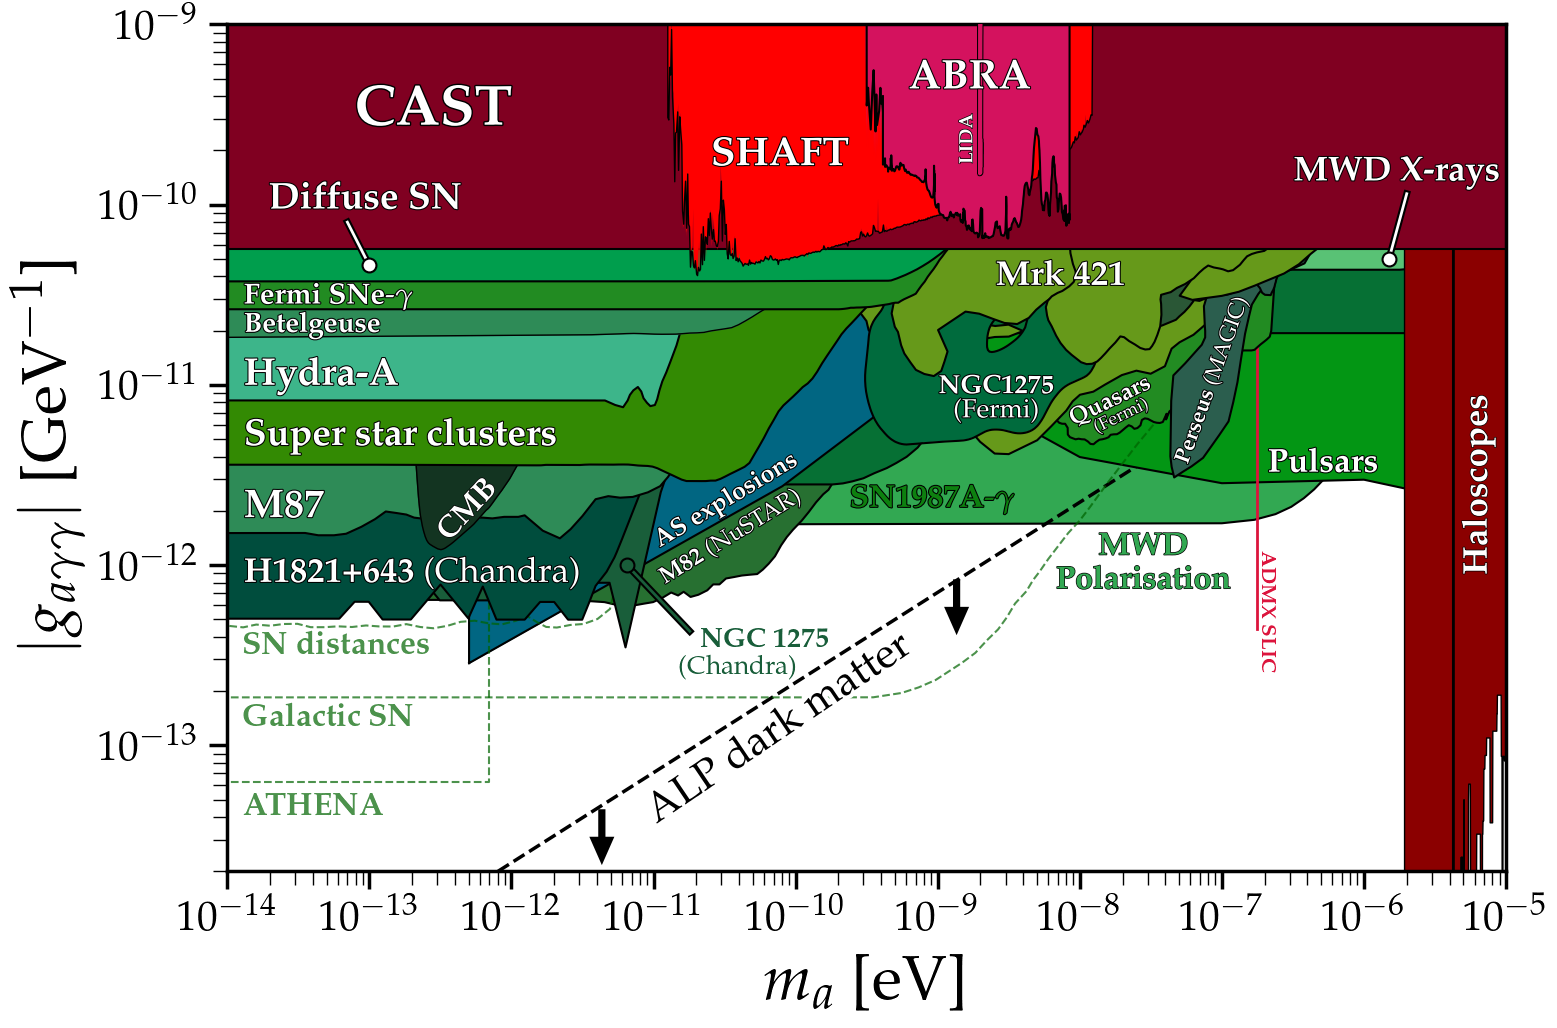

In [16]:
%matplotlib inline
from numpy import *
import matplotlib.pyplot as plt
from PlotFuncs import BlackHoleSpins, AxionPhoton, MySaveFig, col_alpha, FigSetup,FilledLimit, line_background
import matplotlib.patheffects as pe
pek=[pe.Stroke(linewidth=5, foreground='k',alpha=1), pe.Normal()]


fig,ax = FigSetup(Shape='Rectangular',ylab='$|g_{a\gamma\gamma}|$ [GeV$^{-1}$]',mathpazo=True,xtick_rotation=0,tfs=30,\
                 m_min=1e-14,m_max=1e-5,g_min=2e-14,g_max=1e-9)
y2 = ax.get_ylim()[1]


AxionPhoton.Helioscopes(ax,projection=False,text_on=False)
AxionPhoton.LowMassAstroBounds(ax,projection=False,text_on=False,lw=1.5)
AxionPhoton.ALPdecay(ax,projection=False,text_on=False) 

# Experiments
plt.gcf().text(0.25,0.80,r'{\bf CAST}',color='w',fontsize=41,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(2.0,'k'))

# DSNALP
plt.gcf().text(0.15,0.72,r'{\bf Diffuse SN}',color='w',fontsize=27,rotation=0,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1.5,'k'))
plt.plot([0.7e-13,1e-13],[0.8e-10,4.6e-11],'-',lw=2,color='w',path_effects=pek)
plt.plot(1e-13,4.6e-11,'ko',lw=3,markersize=10,mfc='w',mew=1.5)

# Pulsars
plt.text(2.1e-7,3.3e-12,r'{\bf Pulsars}',rotation=0,color='w',fontsize=24,path_effects=line_background(1.5,'k'))

# Fermi SN
plt.gcf().text(0.135,0.632,r'{\bf Fermi SNe}-$\gamma$',color='w',fontsize=21,rotation=0,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1.5,'k'))

# Fermi quasars
plt.text(0.8e-8,0.6e-11,r'{\bf Quasars}',color='w',fontsize=17,rotation=26,path_effects=line_background(1.5,'k'))
plt.text(0.8e-8*1.5,0.6e-11/1.1,r'(Fermi)',color='w',fontsize=13,rotation=26,path_effects=line_background(1.5,'k'))
    

# Hydra A
plt.gcf().text(0.135,0.56,r'{\bf Hydra-A}',color='w',fontsize=28,rotation=0,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1.5,'k'))

# Super star cluster
plt.gcf().text(0.135,0.505,r'{\bf Super star clusters}',color='w',fontsize=27,rotation=0,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1.5,'k'))

# M87
plt.gcf().text(0.135,0.44,r'{\bf M87}',color='w',fontsize=29,rotation=0,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1.5,'k'))


# M87
plt.text(1.15e-11,0.83e-12,r'{\bf M82} (NuSTAR)',color='w',fontsize=17,rotation=31.5,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1.5,'k'))



# Distance ladder
dat = loadtxt("limit_data/AxionPhoton/Projections/SN_distances.txt")
plt.plot(dat[:,0],dat[:,1],'--',lw=1.5,zorder=0.091,alpha=0.7,color='darkgreen')
plt.text(0.13e-13,3.5e-13,r'{\bf SN distances}',color='darkgreen',alpha=0.7,fontsize=23,rotation=0,rotation_mode='anchor',ha='left',va='center')


# ATHENA
dat = loadtxt("limit_data/AxionPhoton/Projections/ATHENA.txt")
plt.plot(dat[:,0],dat[:,1],'--',lw=1.5,zorder=0.091,alpha=0.7,color='darkgreen')
plt.text(0.13e-13,4.5e-14,r'{\bf ATHENA}',color='darkgreen',alpha=0.7,fontsize=23,rotation=0,rotation_mode='anchor',ha='left',va='center')



# Fermi galactic SN
dat = loadtxt("limit_data/AxionPhoton/Projections/FermiSN.txt")
plt.plot(dat[:,0],dat[:,1],'--',color='darkgreen',lw=1.5,zorder=-0.01,alpha=0.7)
plt.text(0.13e-13,1.4e-13,r'{\bf Galactic SN}',color='darkgreen',alpha=0.7,fontsize=23,rotation=0,zorder=0.0,rotation_mode='anchor',ha='left',va='center')

# SN1987
plt.text(0.24e-9,2.3e-12,r'{\bf SN1987A}-$\gamma$',color=[0.05, 0.5, 0.06],fontsize=23,rotation=0,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1.5,'k'))
# plt.plot([0.55e-9,2e-10],[3e-12,1e-11],'-',lw=2,color=[0.05, 0.5, 0.06],path_effects=pek)
# plt.plot(2e-10,1e-11,'ko',lw=3,markersize=10,mfc=[0.05, 0.5, 0.06],mew=1.5)


# Chandra
plt.gcf().text(0.135,0.38,r'{\bf H1821+643} (Chandra)',color='w',fontsize=25,rotation=0,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1.5,'k'))
plt.text(0.6e-10,0.35e-12,r'{\bf NGC 1275}',color='#195e3a',fontsize=20,ha='center')
plt.text(0.4e-10,0.35e-12/1.4,r'(Chandra)',color='#195e3a',fontsize=19,ha='center')
plt.plot([0.18e-10,0.65e-11],[0.43e-12,1e-12],'-',lw=2,color='#195e3a',path_effects=pek)
plt.plot(0.65e-11,1e-12,'ko',lw=3,markersize=10,mfc='#195e3a',mew=1.5)

# Fermi
plt.gcf().text(0.591,0.55,r'{\bf NGC1275}',color='w',fontsize=19,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))
plt.gcf().text(0.591,0.528,r'(Fermi)',color='w',fontsize=19,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

# Mrk 421
plt.gcf().text(0.63,0.65,r'{\bf Mrk 421}',color='w',fontsize=25,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))

# HESS
#plt.text(3.4e-8,1.65e-11,r'{\bf PKS}',color='#2a5736',fontsize=17,rotation=0,rotation_mode='anchor',ha='center',va='center')
#plt.text(3.4e-8,1.65e-11/1.35,r'{\bf 2155-304}',color='#2a5736',fontsize=17,rotation=0,rotation_mode='anchor',ha='center',va='center')
#plt.text(3.4e-8,1.65e-11/1.35**2,r'{\bf (HESS)}',color='#2a5736',fontsize=17,rotation=0,rotation_mode='anchor',ha='center',va='center')

# MWD X-rays
plt.text(1.7e-6,1.5e-10,r'{\bf MWD X-rays}',color='w',fontsize=25,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))
plt.plot([1.5e-6,2e-6],[5.0e-11,1.15e-10],'-',lw=2,color='w',path_effects=pek)
plt.plot(1.5e-6,5.0e-11,'ko',lw=3,markersize=10,mfc='w',mew=1.5)

# HAWC
#plt.text(2.5e-7,2.3e-11,r'{\bf TeV blazars}',color='#2b5e4e',fontsize=19.5,rotation=0,rotation_mode='anchor',ha='center',va='center')
#plt.text(2.5e-7,1.6e-11,r'{\bf (HAWC)}',color='#2b5e4e',fontsize=19.5,rotation=0,rotation_mode='anchor',ha='center',va='center')

# MWD Pol.
plt.text(0.28e-7,0.2e-11/1.6,r'{\bf MWD}',color='#32a852',fontsize=23,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1,'k'))
plt.text(0.28e-7,0.13e-11/1.6,r'{\bf Polarisation}',color='#32a852',fontsize=23,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1,'k'))
# plt.plot([3.5e-8,3e-7],[1.5e-12,1e-11],'-',lw=2,color='#32a852',path_effects=pek)
# plt.plot(3e-7,1e-11,'ko',lw=3,markersize=10,mfc='#32a852',mew=1.5)

# Betelgeuse
dat = loadtxt('limit_data/AxionPhoton/Betelgeuse.txt')
plt.fill_between(dat[:,0],dat[:,1],y2=1e0,color='seagreen',zorder=0.235)
plt.plot(dat[:,0],dat[:,1],'k-',zorder=0.235,lw=1)
plt.gcf().text(0.135,0.606,r'{\bf Betelgeuse}',color='w',fontsize=20,rotation=0,rotation_mode='anchor',ha='left',va='center',path_effects=line_background(1.5,'k'))

# CMB Patchy screening
dat = loadtxt('limit_data/AxionPhoton/Planck_unWISE.txt')
plt.fill_between(dat[:,0],dat[:,1],y2=1e0,color='#133421',zorder=0.2191)
plt.plot(dat[:,0],dat[:,1],'k-',zorder=0.2191,lw=1)
plt.text(5e-13,2e-12,r'{\bf CMB}',color='w',fontsize=22,rotation=47,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1,'k'))

MySaveFig(fig,'AxionPhoton_AstroCloseUp_withoutHaloscopes')

AxionPhoton.AxionStarExplosions(ax,text_on=False) 
plt.text(0.95e-11,1.27e-12,r'{\bf AS explosions',fontsize=18,color='w',rotation=31,path_effects=line_background(1.5,'k'))


# ALP dark matter
plt.arrow(0.567, 0.373, 0.00, -0.025, head_width=0.01, head_length=0.017, linewidth=4, color='k', length_includes_head=False,transform=fig.transFigure,figure=fig)
plt.arrow(0.352, 0.164, 0.00, -0.025, head_width=0.01, head_length=0.017, linewidth=4, color='k', length_includes_head=False,transform=fig.transFigure,figure=fig)
plt.gcf().text(0.375,0.155,r'ALP dark matter',fontsize=30,rotation=34,path_effects=line_background(6,'w'))
dat = loadtxt("limit_data/AxionPhoton/ALP_CDM.txt")
plt.plot(dat[:,0],dat[:,1],'k--',lw=2.5,zorder=-10,alpha=1)

# Haloscopes
AxionPhoton.ADMX_SLIC(ax,text_on=True,fs=15,text_shift=[0.85,0.6])
PlotBound(ax,"limit_data/AxionPhoton/Haloscopes_Combined_microeV-meV.txt",facecolor='darkred',zorder=0.1,lw=1)
AxionPhoton.SHAFT(ax,text_on=False,lw=1.0,edgealpha=1)
AxionPhoton.ABRACADABRA(ax,text_on=False,lw=1.5,edgealpha=1)
AxionPhoton.LIDA(ax,text_on=True,text_pos=[1.4e-9,1.8e-10],fs=14)

plt.text(4.9e-6,1e-12,r'{\bf Haloscopes}',color='w',rotation=90,fontsize=25,path_effects=line_background(1,'k'))
plt.gcf().text(0.575,0.83,r'{\bf ABRA}',color='w',fontsize=30,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))
plt.gcf().text(0.46,0.76,r'{\bf SHAFT}',color='w',fontsize=29,rotation=0,rotation_mode='anchor',ha='center',va='center',path_effects=line_background(1.5,'k'))


# MAGIC
plt.text(4.5e-8,0.38e-11,r'{\bf Perseus} (MAGIC)',color='w',fontsize=16,rotation=70,path_effects=line_background(1.5,'k'))


MySaveFig(fig,'AxionPhoton_AstroCloseUp')

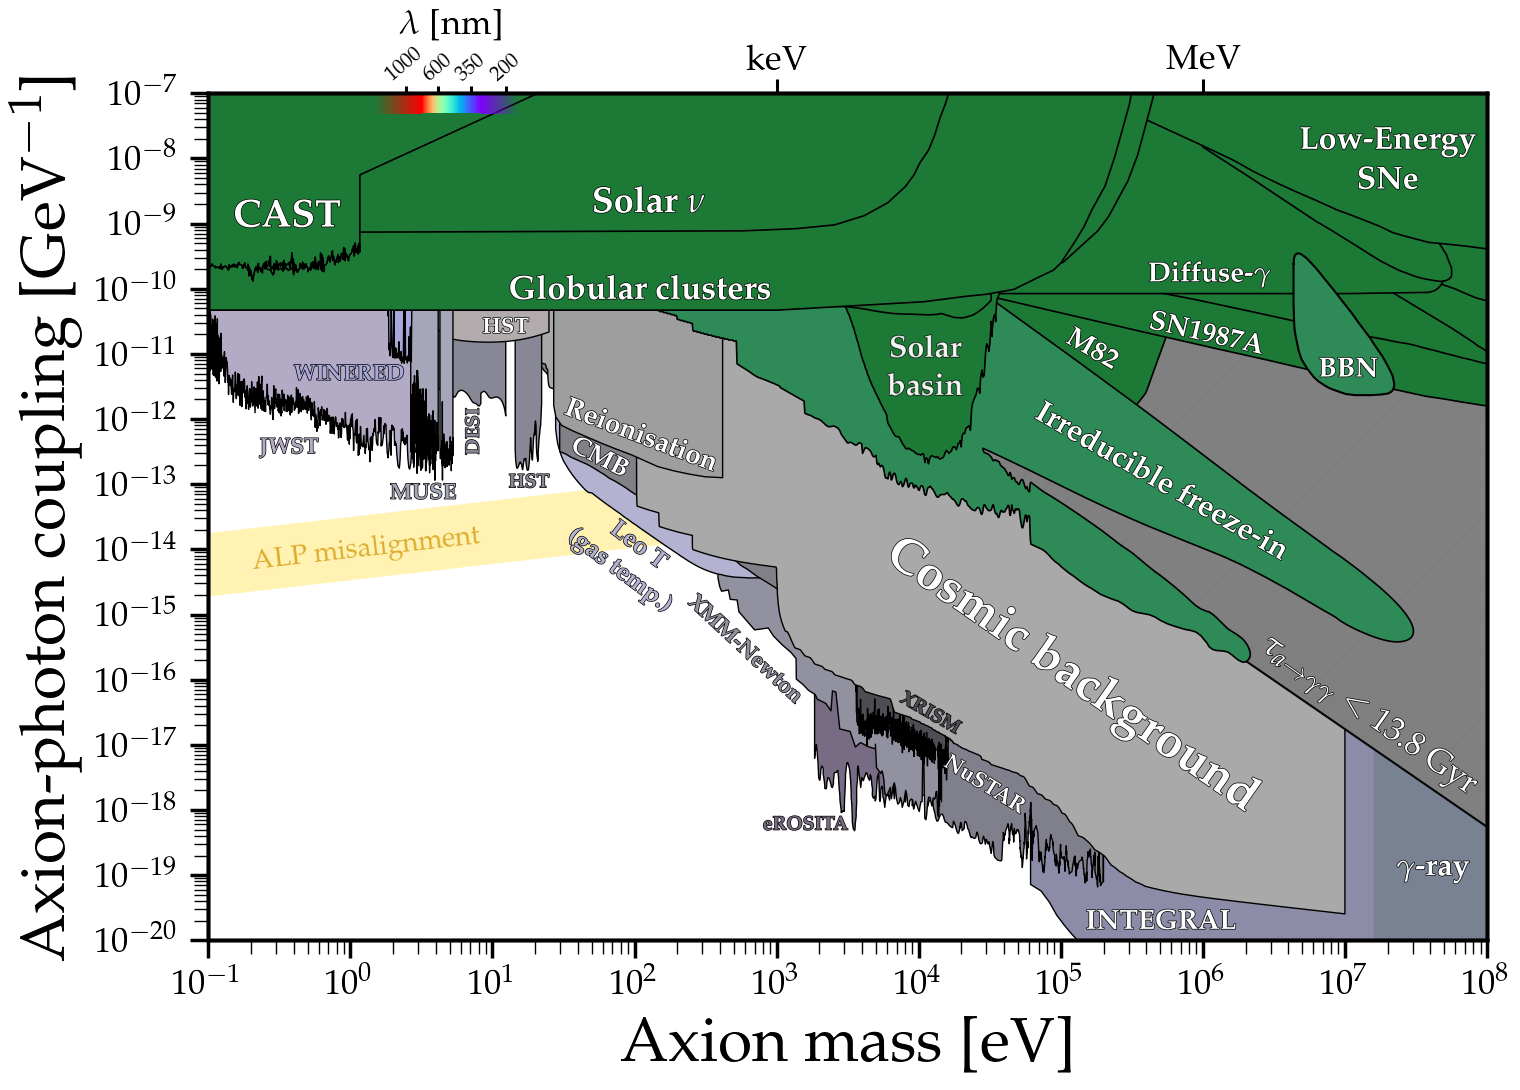

In [16]:
import matplotlib as mpl
from PlotFuncs import MySquarePlot,AxionPhoton,MySaveFig,UpperFrequencyAxis_Simple,col_alpha,FigSetup,line_background,PlotBound
from numpy import *
import matplotlib.pyplot as plt
import matplotlib.cm as cm

pek = line_background(0.75,'k')

fig,ax = FigSetup(xlab='Axion mass [eV]',ylab='Axion-photon coupling [GeV$^{-1}$]',m_min=1e-1,m_max=1e8,g_min=1e-20,g_max=1e-7,xtick_rotation=0,mathpazo=True)

AxionPhoton.QCDAxion(ax,C_center=abs(5/3-1.92)*(44/3-1.92)/2,C_width=0.7,vmax=1.1,KSVZ_on=False,DFSZ_on=False)
#plt.text(0.1e-8,0.2e-19,r'{\bf QCD axion}',fontsize=30,color='goldenrod',rotation=52,alpha=1,path_effects=line_background(0.75,'k'))

# colors
Astro = 'seagreen'
AstroDM = [0.7,0.7,0.7]
ExperimentDM = 'royalblue'
ExperimentLab = '#a83246'
ExperimentStellar = 'seagreen'
Collider = '#a83246'

green2 = '#1d7a36'
gray_late = [0.75,0.75,0.8]
gray_early = [0.6,0.6,0.65]


PlotBound(ax,"limit_data/AxionPhoton/CAST_highm.txt",facecolor=green2,zorder=0.14,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/CAST.txt",facecolor=green2,zorder=0.14,lw=1.2)

PlotBound(ax,"limit_data/AxionPhoton/GlobularClusters.txt",facecolor=green2,zorder=0.1,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/SolarNu.txt",facecolor=green2,zorder=0.11,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/WhiteDwarfs.txt",facecolor=green2,zorder=0.09,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/SN1987A_decay.txt",facecolor=green2,zorder=0.0,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/SNe-decay-Fiorillo.txt",facecolor=green2,zorder=0.08,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/SN1987A_PVO.txt",facecolor=green2,zorder=0.079,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/GW170817.txt",facecolor=green2,zorder=0.07,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/GW170817_Fermi.txt",facecolor=green2,zorder=0.07,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/DiffuseGammaRays.txt",facecolor=green2,zorder=0.07,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/SolarBasin_Beaufort.txt",facecolor=green2,zorder=0.07,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/StAB.txt",facecolor=green2,zorder=0.07,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/M82_decay.txt",facecolor=green2,zorder=-0.01,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/IrreducibleFreezeIn.txt",facecolor=Astro,zorder=0.06,lw=1.2)
PlotBound(ax,"limit_data/AxionPhoton/BBN_10MeV.txt",facecolor=Astro,zorder=0.1,lw=1.5,skip=1)

edgecolor = 'k'

PlotBound(ax,"limit_data/AxionPhoton/JWST_Pinetti.txt",facecolor=array([1,0.95,1.11])*0.7,zorder=0,lw=1,edgecolor=edgecolor,skip=3)
PlotBound(ax,"limit_data/AxionPhoton/DESI.txt",facecolor=array([1,1,1.11])*0.53,zorder=0,lw=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/HST_dwarfs.txt",facecolor=array([1,1,1.11])*0.53,zorder=0,lw=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/HST.txt",facecolor=array([1.04,1,1.02])*0.67,zorder=0,lw=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/Telescopes_MUSE.txt",facecolor=array([1,1,1.13])*0.65,zorder=0,lw=1,edgecolor=edgecolor)
#PlotBound(ax,"limit_data/AxionPhoton/JWST.txt",facecolor=array([1,1.03,1.14])*0.5,zorder=0,lw=1,edgecolor=edgecolor,skip=3)
PlotBound(ax,"limit_data/AxionPhoton/WINERED.txt",facecolor=array([1,1,1.3])*0.66,zorder=0,lw=1,edgecolor=edgecolor,skip=200)
PlotBound(ax,"limit_data/AxionPhoton/LeoT.txt",facecolor=array([1,1,1.17])*0.7,zorder=-1,lw=1,skip=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/CMB_Anisotropies.txt",facecolor=array([1,1,1.05])*0.5,zorder=-1,lw=1,skip=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/x_ion.txt",facecolor=array([1,1,1])*0.62,zorder=0,lw=1,skip=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/CosmicBackground.txt",facecolor='darkgray',zorder=-1,lw=1,skip=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/GammaRayAttenuation.txt",facecolor=array([0.95,1.02,1.15])*0.5,zorder=-2,lw=1,skip=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/GammaRayDecayCompilation.txt",facecolor=array([0.95,1.02,1.15])*0.5,zorder=-10,lw=1,skip=1,edgecolor=edgecolor)


PlotBound(ax,"limit_data/AxionPhoton/XRISM.txt",facecolor=array([1,1,1.1])*0.3,zorder=-2.9,lw=1,skip=4,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/XMM-Newton.txt",facecolor=array([1,1,1.1])*0.57,zorder=-3,lw=1,skip=4,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/NuSTAR.txt",facecolor=array([1,1,1.1])*0.5,zorder=-4,lw=1,skip=4,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/INTEGRAL.txt",facecolor=array([1,1,1.2])*0.55,zorder=-5,lw=1,skip=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/XRAY.txt",facecolor=array([1,1,1.1])*0.57,zorder=-6,lw=1,skip=1,edgecolor=edgecolor)
PlotBound(ax,"limit_data/AxionPhoton/eROSITA.txt",facecolor=array([1,0.9,1.1])*0.47,zorder=-7,lw=1,skip=1,edgecolor=edgecolor)





ax.text(1.5e-1,0.9e-9,r'{\bf CAST}',color='w',fontsize=28,rotation=0,path_effects=line_background(1,'k'))
ax.text(5e1,1.5e-9,r'{\bf Solar $\nu$}',color='w',fontsize=26,rotation=0,alpha=1,path_effects=line_background(1,'k'))
ax.text(1.3e1,0.7e-10,r'{\bf Globular clusters}',color='w',fontsize=24,rotation=0,alpha=1,path_effects=line_background(1,'k'))
ax.text(6e3,0.9e-11,r'\begin{center}{\bf Solar \linebreak basin}\end{center}',color='w',fontsize=22,alpha=0.8,path_effects=line_background(1,'k'))

ax.text(6e4,0.07e-13,r'{\bf Irreducible freeze-in}',color='w',fontsize=22,rotation=-30,alpha=1,path_effects=line_background(1,'k'))
ax.text(4.1e5,1.3e-10,r'{\bf Diffuse-$\gamma$}',color='w',fontsize=20,rotation=0,alpha=1,path_effects=line_background(1,'k'))
ax.text(1e5,0.6e-11,r'{\bf M82}',color='w',fontsize=20,rotation=-30,alpha=1,path_effects=line_background(1,'k'))

ax.text(4e5,1e-11,r'{\bf SN1987A}',color='w',fontsize=20,rotation=-13,alpha=1,path_effects=line_background(1,'k'))
ax.text(2e7,0.3e-7,r'\begin{center}{\bf Low-Energy} \linebreak {\bf SNe}\end{center}',fontsize=23,color='w',rotation=0,ha='center',va='top',alpha=1,path_effects=line_background(1,'k'))
ax.text(0.65e7,4.5e-12,r'{\bf BBN}',color='w',fontsize=20,rotation=0,path_effects=line_background(1,'k'))
#ax.text(0.4e8,0.9e-10,r'{\bf GW170817}',color='w',fontsize=14,rotation=0,path_effects=line_background(1,'k'))

ax.text(13,0.9e-13,r'{\bf HST}',color=array([1,1,1.11])*0.53,fontsize=14,rotation=0,path_effects=line_background(1,'k'))
ax.text(1.9,0.6e-13,r'{\bf MUSE}',color=array([1,1,1.13])*0.65,fontsize=16,rotation=0,path_effects=line_background(1,'k'))
ax.text(6.4,0.34e-12,r'{\bf DESI}',color=array([1,1,1.11])*0.53,fontsize=14,rotation=90,path_effects=line_background(1,'k'))
ax.text(8.5,2.1e-11,r'{\bf HST}',color='w',fontsize=16,rotation=0,path_effects=line_background(1,'k'))
ax.text(0.23,0.3e-12,r'{\bf JWST}',color=array([1,0.95,1.11])*0.7,fontsize=16,rotation=0,path_effects=line_background(1,'k'))
ax.text(0.4,0.4e-11,r'{\bf WINERED}',color=array([1,1,1.3])*0.66,fontsize=16,rotation=0,path_effects=line_background(1,'k'))

#ax.text(11.4,0.45e-11,r'\begin{center}{\bf $\gamma$-ray \linebreak atten.}\end{center}',color=array([0.95,1.02,1.15])*0.5,fontsize=10,rotation=-50,path_effects=line_background(0.5,'k'))



ax.text(0.3e2,1.6e-13,r'{\bf Reionisation}',color='w',fontsize=20,rotation=-21,path_effects=line_background(1,'k'))
ax.text(0.33e2,1.3e-13,r'{\bf CMB}',color='w',fontsize=18.5,rotation=-27,path_effects=line_background(1,'k'))
ax.text(3.1e1,0.33e-14,r'\begin{center}{\bf Leo T \linebreak (gas temp.)}\end{center}',color=array([1,1,1.17])*0.7,fontsize=18,rotation=-37,path_effects=line_background(1,'k'))


ax.text(0.7e4,1.5e-17,r'{\bf XRISM}',color=array([1,1,1.1])*0.3,fontsize=14,rotation=-30,path_effects=line_background(1,'k'))
ax.text(2.2e2,0.45e-16,r'{\bf XMM-Newton}',color=array([1,1,1.1])*0.57,fontsize=16,rotation=-43,path_effects=line_background(1,'k'))
ax.text(1.4e4,0.9e-18,r'{\bf  NuSTAR}',color='w',fontsize=16,rotation=-32,path_effects=line_background(1,'k'))
ax.text(0.15e6,0.15e-19,r'{\bf INTEGRAL}',color='w',fontsize=20,rotation=0,path_effects=line_background(1,'k'))
ax.text(2.3e7,0.1e-18,r'{\bf $\gamma$-ray}',color='w',fontsize=22,rotation=0,path_effects=line_background(1,'k'))

ax.text(0.005e6,1e-18,r'{\bf Cosmic background}',color='w',fontsize=35,rotation=-35,path_effects=line_background(1,'k'))

ax.text(8.0e2,0.5e-18,r'{\bf eROSITA}',color=array([1,0.9,1.1])*0.47,fontsize=14,rotation=0,path_effects=line_background(1,'k'))


ax.text(0.23e7,0.18e-17,r'$\tau_{a\to\gamma\gamma} <$ 13.8 Gyr',color='w',fontsize=24,rotation=-35,path_effects=line_background(1,'k'))





# Post-inflation ALPs from strings
def ALP_n0(m,gstar_T1=90,C_agamma=1):
    g = C_agamma/(137*2*pi)*sqrt(2*5.45)/1.9e13*(m/1e-6)**(1/4)*(90/gstar_T1)**(1/8)
    return g
m = array([1e-12,1e8])
ax.fill_between(m,ALP_n0(m,60,0.5),ALP_n0(m,100,5.0),color='gold',alpha=0.3,lw=0,zorder=-10)
ax.text(0.2,0.5e-14,'ALP misalignment',fontsize=20,color='goldenrod',alpha=0.9,rotation=6.5)


s2eV = 1/6.5821e-16
m2eV = 1/1.9732705e-7
mvals = logspace(0,15,100)
g_tau = lambda tau : 1e9*sqrt(64*pi/(mvals**3*tau*s2eV))
#plt.fill_between(mvals,g_tau(3600*24*365*13.8e9),y2=1,facecolor='dimgray',edgecolor='k',hatch='/',zorder=-0.1)

plt.fill_between(mvals,g_tau(3600*24*365*13.8e9),y2=1e0,zorder=-0.1,lw=1.5,color='gray',edgecolor='k')
plt.fill_between(mvals,g_tau(3600*24*365*13.8e9),y2=1,zorder=-0.1,lw=0.5,edgecolor='dimgray',facecolor='none',hatch='/',alpha=0.1)


mvals = geomspace(4*pi/(300e-9*m2eV),4*pi/(780e-9*m2eV),100)
gvals = geomspace(5e-8,1e-7,20)
[M,G] = meshgrid(mvals,gvals)
ax.pcolormesh(M,G,1/M,cmap='rainbow',vmin=1/mvals[0],vmax=1/mvals[-1],zorder=10)
ax.pcolormesh(M,G,1/M,cmap='rainbow',vmin=1/mvals[0],vmax=1/mvals[-1],zorder=10)


col1 = cm.rainbow([1.0])
nlayers = 100
mmax = geomspace(1.5e0,mvals[-1],nlayers)
alpha = linspace(0.0,1.0,nlayers)
for i in range(1,nlayers):
    plt.fill_between([mmax[i-1],mmax[i]],[gvals[0]/1.02,gvals[0]/1.02],y2=gvals[-1],lw=0,alpha=alpha[i],color=col1,zorder=10)


col1 = cm.rainbow([0.0])
nlayers = 100
mmax = flipud(geomspace(mvals[0],15,nlayers))
alpha = linspace(0.0,1.0,nlayers)
for i in range(1,nlayers):
    plt.fill_between([mmax[i-1],mmax[i]],[gvals[0]/1.02,gvals[0]/1.02],y2=gvals[-1],lw=0,alpha=alpha[i],color=col1,zorder=10)



ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xscale('log')
ax2.tick_params(length=5,width=2.2,pad=0)


lamb_vals = array([200e-9,350e-9,600e-9,1e-6])
ax2.set_xticks(((4*pi/(m2eV*lamb_vals))))
ax2.set_xticklabels(['200','350','600','1000'],fontsize=15,rotation=40)
plt.text(2.2,0.8e-6,r'$\lambda$ [nm]',fontsize=25)


ax3 = ax.twiny()
ax3.set_xlim(ax.get_xlim())
ax3.set_xscale('log')
ax3.tick_params(length=10,width=2.2,pad=0)
ax3.set_xticks([1000,1e6])
ax3.set_xticklabels(['keV','MeV'])





MySaveFig(fig,'AxionPhoton_HeavyAxionDecayCloseUp')

